In [2]:
!pip install matplotlib


/Users/dhairyabhatt/code_dir/Data analytics projects/world_health/world_bank/bin/pip: line 2: /Users/dhairyabhatt/code_dir/Data analytics projects/world_bank/world_bank/bin/python: No such file or directory
/Users/dhairyabhatt/code_dir/Data analytics projects/world_health/world_bank/bin/pip: line 2: exec: /Users/dhairyabhatt/code_dir/Data analytics projects/world_bank/world_bank/bin/python: cannot execute: No such file or directory


In [2]:
# Cell 1 — Phase 4 Setup: Imports & Load Q2 Dataset

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_PATH = "/Users/dhairyabhatt/code_dir/Data analytics projects/world_health/data"
OUTPUT_PATH = os.path.join(BASE_PATH, "phase3_outputs")

q2 = pd.read_csv(os.path.join(OUTPUT_PATH, "q2_hale_vs_le.csv"))

print(q2.shape)
print(q2.dtypes)
print(q2["dim1"].unique())
q2.head()

Matplotlib is building the font cache; this may take a moment.


(2196, 6)
country           str
year            int64
dim1              str
hale          float64
le            float64
hale_yield    float64
dtype: object
<StringArray>
['Both sexes', 'Male', 'Female']
Length: 3, dtype: str


,country,year,dim1,hale,le,hale_yield
0,Afghanistan,2019,Both sexes,53.95,63.21,0.853504
1,Afghanistan,2019,Male,54.73,63.29,0.864750
2,Afghanistan,2019,Female,53.15,63.16,0.841514
3,Afghanistan,2015,Both sexes,52.60,61.65,0.853204
4,Afghanistan,2015,Male,52.78,61.04,0.864679


In [3]:
# Cell 2 — Global Trend: HALE vs LE (2000–2019)
# Unweighted mean across countries per year (no population data exists to weight by)

global_trend = (
    q2[q2["dim1"] == "Both sexes"]
    .groupby("year")[["hale", "le"]]
    .mean()
    .reset_index()
)

global_trend.head()

,year,hale,le
0,2000,58.472678,66.749016
1,2010,61.267814,70.004481
2,2015,62.499235,71.500328
3,2019,63.314973,72.540492


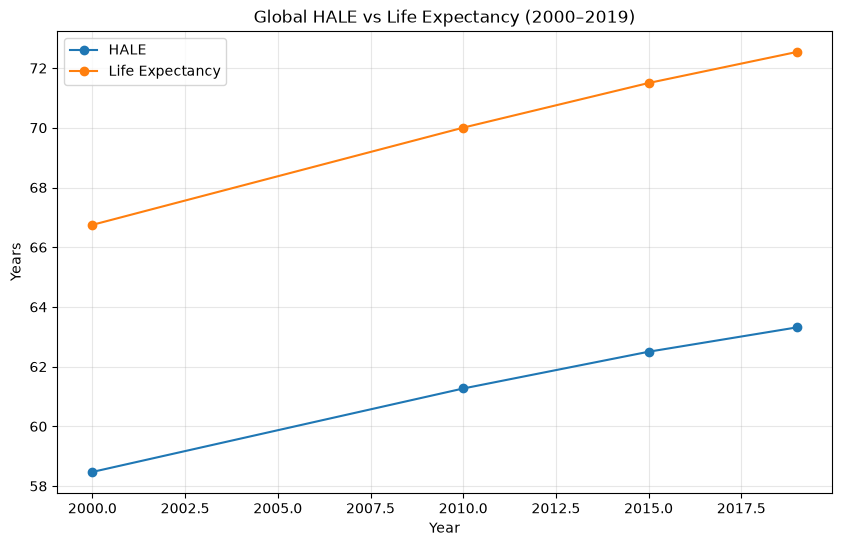

In [4]:
# Cell 3 — Plot Global HALE vs LE Trend

plt.figure(figsize=(10, 6))
plt.plot(global_trend["year"], global_trend["hale"], label="HALE", marker="o")
plt.plot(global_trend["year"], global_trend["le"], label="Life Expectancy", marker="o")
plt.xlabel("Year")
plt.ylabel("Years")
plt.title("Global HALE vs Life Expectancy (2000–2019)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

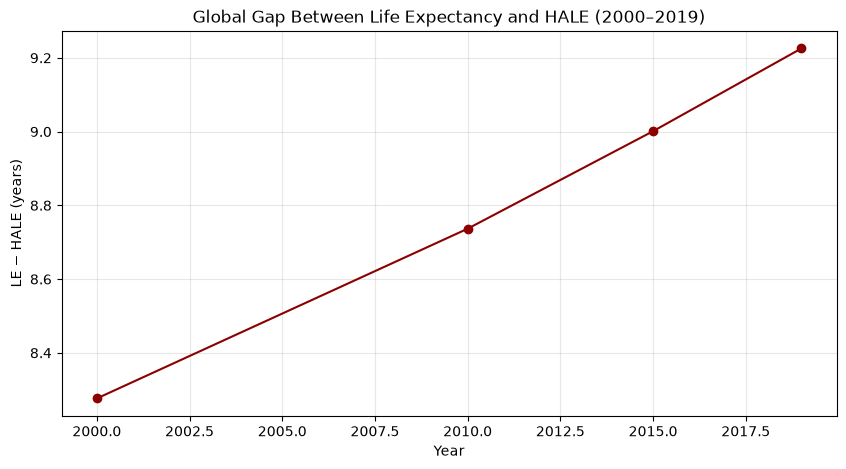

   year       gap
0  2000  8.276339
1  2010  8.736667
2  2015  9.001093
3  2019  9.225519


In [5]:
# Cell 4 — Gap Between LE and HALE Over Time
# gap = years lived without full health; rising gap = HALE not keeping pace with LE

global_trend["gap"] = global_trend["le"] - global_trend["hale"]

plt.figure(figsize=(10, 5))
plt.plot(global_trend["year"], global_trend["gap"], color="darkred", marker="o")
plt.xlabel("Year")
plt.ylabel("LE − HALE (years)")
plt.title("Global Gap Between Life Expectancy and HALE (2000–2019)")
plt.grid(alpha=0.3)
plt.show()

print(global_trend[["year", "gap"]])

In [6]:
# Cell 5 — Has HALE Improved Faster or Slower Than LE?
# Compare total change and CAGR over the full window

start = global_trend.iloc[0]
end = global_trend.iloc[-1]
n_years = end["year"] - start["year"]

hale_total_change = end["hale"] - start["hale"]
le_total_change = end["le"] - start["le"]

hale_cagr = (end["hale"] / start["hale"]) ** (1 / n_years) - 1
le_cagr = (end["le"] / start["le"]) ** (1 / n_years) - 1

print(f"HALE: {start['hale']:.2f} -> {end['hale']:.2f}  (+{hale_total_change:.2f} yrs, CAGR {hale_cagr*100:.3f}%/yr)")
print(f"LE:   {start['le']:.2f} -> {end['le']:.2f}  (+{le_total_change:.2f} yrs, CAGR {le_cagr*100:.3f}%/yr)")
print(f"Gap:  {start['gap']:.2f} -> {end['gap']:.2f}")

HALE: 58.47 -> 63.31  (+4.84 yrs, CAGR 0.420%/yr)
LE:   66.75 -> 72.54  (+5.79 yrs, CAGR 0.439%/yr)
Gap:  8.28 -> 9.23


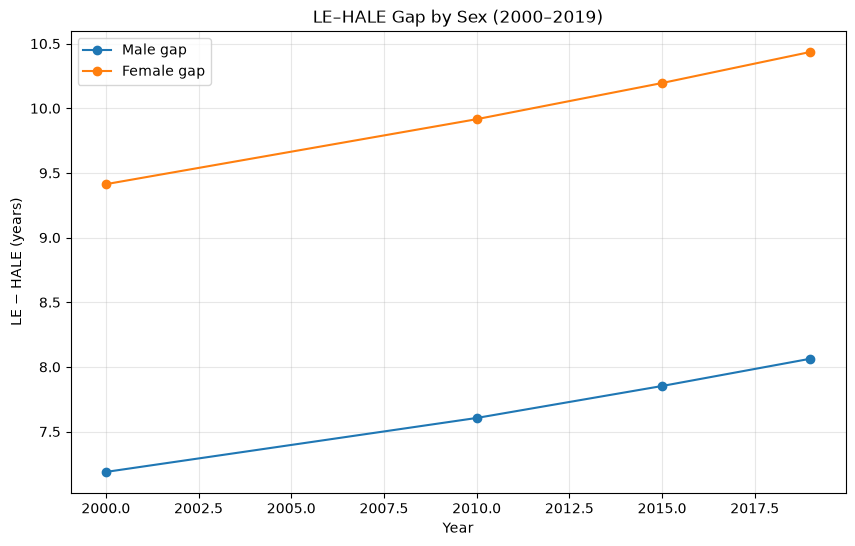

In [7]:
# Cell 6 — Sex-Disaggregated Gap Trend

sex_trend = (
    q2[q2["dim1"].isin(["Male", "Female"])]
    .groupby(["year", "dim1"])[["hale", "le"]]
    .mean()
    .reset_index()
)
sex_trend["gap"] = sex_trend["le"] - sex_trend["hale"]

plt.figure(figsize=(10, 6))
for sex in ["Male", "Female"]:
    subset = sex_trend[sex_trend["dim1"] == sex]
    plt.plot(subset["year"], subset["gap"], label=f"{sex} gap", marker="o")

plt.xlabel("Year")
plt.ylabel("LE − HALE (years)")
plt.title("LE–HALE Gap by Sex (2000–2019)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [8]:
# Cell 7 — Sex Comparison Summary

for sex in ["Male", "Female"]:
    s = sex_trend[sex_trend["dim1"] == sex].sort_values("year")
    s_start, s_end = s.iloc[0], s.iloc[-1]
    print(f"{sex}: HALE +{s_end['hale']-s_start['hale']:.2f} yrs | "
          f"LE +{s_end['le']-s_start['le']:.2f} yrs | "
          f"Gap {s_start['gap']:.2f} -> {s_end['gap']:.2f}")

Male: HALE +4.96 yrs | LE +5.84 yrs | Gap 7.19 -> 8.06
Female: HALE +4.68 yrs | LE +5.71 yrs | Gap 9.41 -> 10.44


In [9]:
# Cell 8 — Top 10 Countries by Average LE–HALE Gap (2000–2019)

both_sexes = q2[q2["dim1"] == "Both sexes"].copy()
both_sexes["gap"] = both_sexes["le"] - both_sexes["hale"]

avg_gap = (
    both_sexes.groupby("country")["gap"]
    .mean()
    .reset_index()
    .rename(columns={"gap": "avg_gap"})
)

top10_avg_gap = avg_gap.sort_values("avg_gap", ascending=False).head(10)

top10_avg_gap

,country,avg_gap
175,United States of America,11.7725
7,Australia,11.6700
116,New Zealand,11.2675
173,United Kingdom of Great Britain and Northern I...,10.8350
158,Switzerland,10.7600
77,Iran (Islamic Republic of),10.7325
120,Norway,10.7075
81,Italy,10.6950
152,Spain,10.6450
88,Kuwait,10.6400


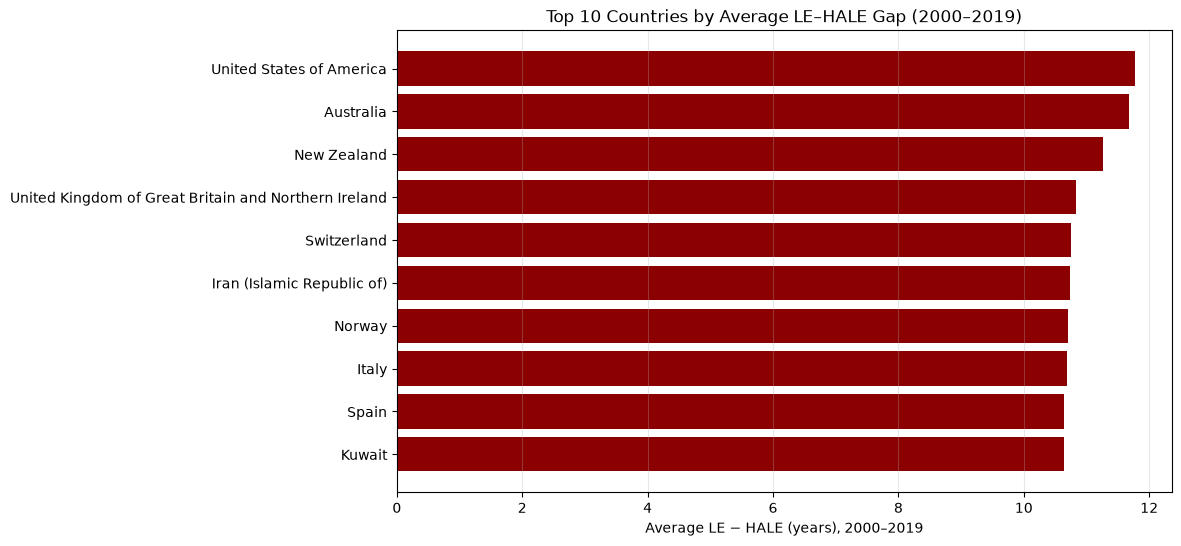

In [10]:
# Cell 9 — Plot Top 10 Countries by Average Gap

plt.figure(figsize=(10, 6))
plt.barh(top10_avg_gap["country"], top10_avg_gap["avg_gap"], color="darkred")
plt.xlabel("Average LE − HALE (years), 2000–2019")
plt.title("Top 10 Countries by Average LE–HALE Gap (2000–2019)")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.show()

In [11]:
# Cell 10 — Average HALE and LE for Top 10 Countries (2000–2019)

top10_countries = top10_avg_gap["country"].tolist()

top10_avg_values = (
    both_sexes[both_sexes["country"].isin(top10_countries)]
    .groupby("country")[["hale", "le"]]
    .mean()
    .reindex(top10_countries)  # keep same order as the gap ranking
    .reset_index()
)

top10_avg_values

,country,hale,le
0,United States of America,66.3050,78.0775
1,Australia,70.0575,81.7275
2,New Zealand,69.4275,80.6950
3,United Kingdom of Great Britain and Northern I...,69.2025,80.0375
4,Switzerland,71.2325,81.9925
5,Iran (Islamic Republic of),64.8750,75.6075
6,Norway,70.3000,81.0075
7,Italy,70.9150,81.6100
8,Spain,70.9350,81.5800
9,Kuwait,69.3075,79.9475


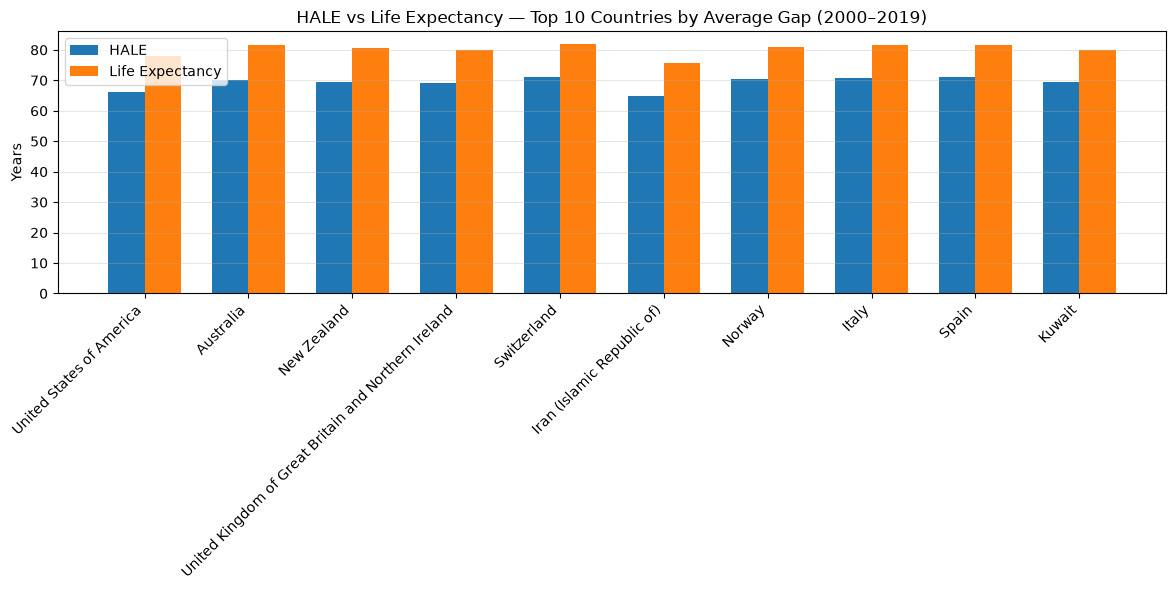

In [12]:
# Cell 11 — Grouped Bar Chart: HALE vs LE for Top 10 Countries

x = np.arange(len(top10_avg_values))
width = 0.35

plt.figure(figsize=(12, 6))
plt.bar(x - width/2, top10_avg_values["hale"], width, label="HALE")
plt.bar(x + width/2, top10_avg_values["le"], width, label="Life Expectancy")

plt.xticks(x, top10_avg_values["country"], rotation=45, ha="right")
plt.ylabel("Years")
plt.title("HALE vs Life Expectancy — Top 10 Countries by Average Gap (2000–2019)")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()